# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**


----

# Trabajo práctico entregable - parte 1


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
import seaborn
seaborn.set_context('talk')

In [16]:
# Cargamos los datos
melb_df = pandas.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df[:3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


### Información acerca de las variables
Suburb: Suburb

Address: Dirección

Rooms: Número de habitaciones

Price: Precio en dólares australianos

Method:
S - propiedad vendida;
SP - propiedad vendida previamente;
PI - propiedad no vendida (pasó en subasta sin alcanzar el precio de reserva);
PN - vendida previamente no divulgada;
SN - vendida no divulgada;
NB - sin oferta;
VB - oferta del vendedor;
W - retirada antes de la subasta;
SA - vendida después de la subasta;
SS - vendida después de la subasta (precio no divulgado).
N/A - precio o oferta más alta no disponible.

Type:
br - dormitorio(s);
h - casa, cabaña, villa, semi-adosado, terraza;
u - unidad, dúplex;
t - casa adosada;
dev site - sitio de desarrollo;
o res - otra residencia.

SellerG: Agente inmobiliario

Date: Fecha de venta

Distance: Distancia al CBD en kilómetros

Regionname: Región general (Oeste, Noroeste, Norte, Noreste, etc.)

Propertycount: Número de propiedades existentes en el suburbio.

Bedroom2 : Número de dormitorios (obtenido de otra fuente)

Bathroom: Número de baños

Car: Número de plazas de aparcamiento

Landsize: Tamaño del terreno en metros cuadrados

BuildingArea: Superficie construida en metros cuadrados

YearBuilt: Año de construcción de la casa

CouncilArea: Área del consejo municipal

Lattitude: Latitud

Longtitude: Longitud


In [3]:
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

## Ejercicio 1: Encoding

1. Seleccionar todas las filas y columnas del conjunto de datos, **excepto** `BuildingArea` y `YearBuilt`.

2. Decidir si elimina algunas filas o columnas en base al análisis de datos faltantes.

3. Hacer un análisis descriptivo de las variables numéricas del conjunto de datos. Todas tienen el tipo `Dtype` correcto asignado? Armar una matriz (array) sólo con las variables numéricas.  

4. Estudiar las variables categóricas del DataFrame. Aplicar una codificación One-hot encoding a las columnas categóricas que crea pertinente. Si lo consideran necesario, pueden reducir el número de categorías únicas de algunas variables. ¿Cómo trataría la variable `Date`? Armar la matriz de variables categóricas codificada.

5. Concatenar la matriz de variables numéricas a la matriz que codifica las variables categóricas resultante del punto anterior.

Algunas opciones:
  1. Utilizar `OneHotEncoder` junto con el parámetro `categories` para las variables categóricas y luego usar `numpy.hstack` para concatenar el resultado con las variables numéricas.
  2. `DictVectorizer` con algunos pasos de pre-proceso previo.

Recordar también que el atributo `pandas.DataFrame.values` permite acceder a la matriz de numpy subyacente a un DataFrame.


#Resolución Ej 1

**Análisis previo del dataset:**

Antes de realizar cualquier transformación, se analiza cuanta categorías únicas tiene cada variable categórica (cardinalidad) y qué porcentaje de valores faltantes hay en cada columna. Esto permite tomar decisiones fundamentales sobre qué columna conservar, cuáles eliminar y cuales requieren un tratamiento especial.




In [4]:
# Ver cardinalidad de cada columna categórica
cat_vars = melb_df.select_dtypes(include='object').columns
for col in cat_vars:
    print(f"{col}: {melb_df[col].nunique()} valores únicos")

Suburb: 314 valores únicos
Address: 13378 valores únicos
Type: 3 valores únicos
Method: 5 valores únicos
SellerG: 268 valores únicos
Date: 58 valores únicos
CouncilArea: 33 valores únicos
Regionname: 8 valores únicos


In [5]:
# Ver porcentaje de datos faltantes
faltantes = melb_df.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(1))

BuildingArea    47.5
YearBuilt       39.6
CouncilArea     10.1
Car              0.5
dtype: float64


**Filas y columnas**



Limpieza previa:

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

melb_data = pd.read_csv('https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')

# Hacemos una copia para no modificar el dataset original
melb_df = melb_data.copy()

# Selección de columnas importantes (sin BuildingArea ni YearBuilt)
melb_df = melb_df.drop(columns=['BuildingArea', 'YearBuilt'])

Se limpian los datos como: Bedroom 2 por ser redundante con Rooms (ambas miden la cantidad de dormitorios, pero provienen de distintas fuentes, lo que puede introducir inconsistencias). Se elimina Address y SellerG por su alta cardinalidad: tienen casi tantos valores únicos como filas, por lo que no aportan capacidad de generalización a un modelo y sólo agregarían un ruido y dimensiones innecesarias.  

Se considera que Landsize con 0 puede ser dato faltante, se reemplaza por NaN.

Luego se eliminan outliers extremos utilizando percentiles.

Se eliminan las filas que no tienen precio.

In [7]:
melb_df = melb_df.drop(columns=['Bedroom2'])

# Address y SellerG
melb_df = melb_df.drop(columns=['Address', 'SellerG'])

# Detectar ceros que son datos faltantes
print(melb_df[melb_df == 0].count(axis=0))

# Reemplazar por NaN Landsize con 0
melb_df['Landsize'] = melb_df['Landsize'].replace(0, np.nan)
melb_df['Car'] = melb_df['Car'].replace(0, np.nan)

# Eliminar outliers extremos
q99_landsize = melb_df['Landsize'].quantile(0.99)
melb_df = melb_df[(melb_df['Landsize'] < q99_landsize) | (melb_df['Landsize'].isnull())]

# Eliminar filas sin precio (variable objetivo)
melb_df = melb_df.dropna(subset=['Price'])


Suburb              0
Rooms               0
Type                0
Price               0
Method              0
Date                0
Distance            6
Postcode            0
Bathroom           34
Car              1026
Landsize         1939
CouncilArea         0
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


Se trata la variable Date.

In [8]:
melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=True)
melb_df['SaleYear']  = melb_df['Date'].dt.year
melb_df['SaleMonth'] = melb_df['Date'].dt.month
melb_df = melb_df.drop(columns=['Date'])

Se separa las variables numéricas y categóricas. Suburb tiene alta cardinalidad (la cantidad de valores únicos que tiene una variable categórica).

Se concatena con las demás variables

In [9]:
# También reducimos CouncilArea
top_councils = melb_df['CouncilArea'].value_counts().nlargest(20).index
melb_df['CouncilArea'] = melb_df['CouncilArea'].where(
    melb_df['CouncilArea'].isin(top_councils), other='Other'
)
# Rellenar NaN con 'Other' para que el encoder no se rompa
melb_df['CouncilArea'] = melb_df['CouncilArea'].fillna('Other')

In [10]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Define cat_cols and num_cols, and create X_num (moved from previous cells)
cat_cols = ['Suburb', 'Type', 'Method', 'Regionname', 'CouncilArea']
num_cols = melb_df.select_dtypes(include='number').columns.tolist()

# Matriz numérica
X_num = melb_df[num_cols].values

X_cat = encoder.fit_transform(melb_df[cat_cols])

X = np.hstack([X_num, X_cat])
print("Shape final:", X.shape)

Shape final: (13463, 360)


In [11]:
# Suburb tiene alta cardinalidad → se puede reducir a top-N o eliminar
top_suburbs = melb_df['Suburb'].value_counts().nlargest(30).index
melb_df['Suburb'] = melb_df['Suburb'].where(melb_df['Suburb'].isin(top_suburbs), other='Other')

cat_cols = ['Suburb', 'Type', 'Method', 'Regionname', 'CouncilArea']
num_cols = melb_df.select_dtypes(include='number').columns.tolist()

# Verificar tipos
print(melb_df.dtypes)

# Matriz numérica
X_num = melb_df[num_cols].values


Suburb            object
Rooms              int64
Type              object
Price            float64
Method            object
Distance         float64
Postcode         float64
Bathroom         float64
Car              float64
Landsize         float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
SaleYear           int32
SaleMonth          int32
dtype: object


## Ejercicio 2: Imputación por KNN

En el teórico se presentó el método `IterativeImputer`, entre otros, para imputar valores faltantes en variables numéricas. Sin embargo, los ejemplos presentados sólo utilizaban algunas variables numéricas presentes en el conjunto de datos. En este ejercicio, utilizaremos la matriz de datos codificada para imputar datos faltantes de manera más precisa.

1. Agregue a la matriz obtenida en el punto anterior las columnas `YearBuilt` y `BuildingArea`.
2. Aplique una instancia de `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar los valores de las variables. ¿Es necesario estandarizar o escalar los datos previamente?
3. Realice un gráfico mostrando la distribución de cada variable antes de ser imputada, y con ambos métodos de imputación.

In [12]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

KNN calcula distancias entre filas. Si una variable va de 0 a 1.000.000, como Price, y otra de 0 a 5 como room, la primera va a dominar completamente el cálculo de distancia y las demás variables no van a importar. Por eso hay que llevar todo a la misma escala.

Se agrega YearBuilt y BuildingArea con sus NaN originales. Se toman del dataset original antes de la limpieza.


In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd

melb_data = pd.read_csv('https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')

# Tomamos YearBuilt y BuildingArea del dataset original (con sus NaN)
extra = melb_data.loc[melb_df.index, ['YearBuilt', 'BuildingArea']].values

# Usamos solo las variables numéricas (X_num).
X_para_imputar = np.hstack([X_num, extra])

# Escalamos antes de imputar
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_para_imputar)

# Imputamos con KNN con menos vecinos para mayor velocidad
imputer = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=3),
    max_iter=20,
    random_state=42
)
X_imputed = imputer.fit_transform(X_scaled)

print("Shape después de imputar:", X_imputed.shape)

Shape después de imputar: (13463, 14)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Gráfico comparativo de distribuciones

El gráfico compara la distribución de los valores originales (solo los que existían, ingorando los NaN) vs la distribución después de la imputación KNN.

Si el imputador es bueno, debería preservar la forma general de la distirbución original. Si el histograma imputado difiere mucho, puede indivar que el modelo de KNN no tuvo suficiente información o que los vecinos encontrados no eran representativos.

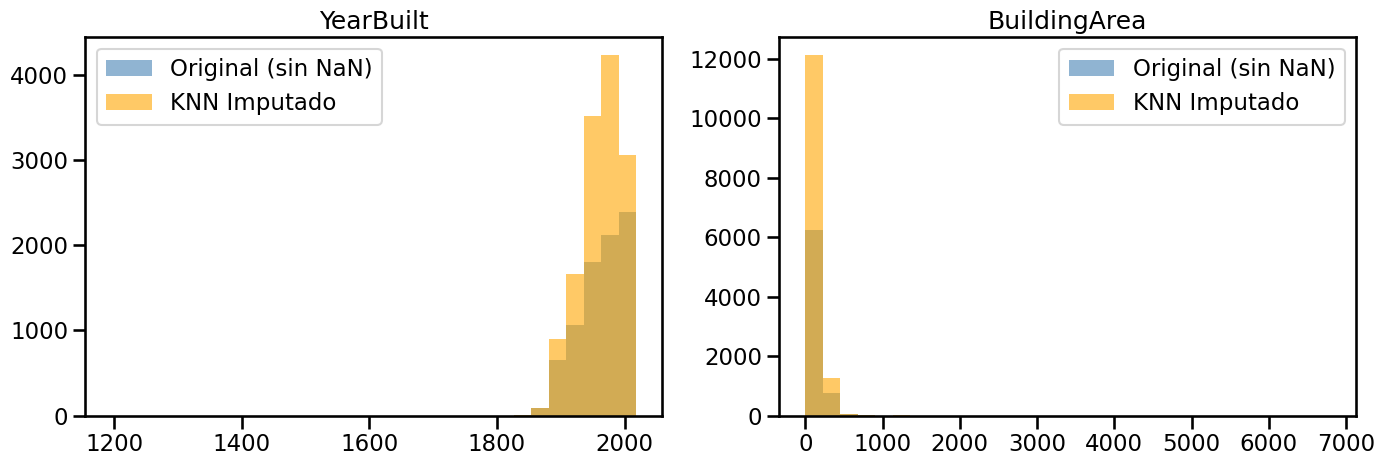

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = ['YearBuilt', 'BuildingArea']

# Índices de YearBuilt y BuildingArea en la matriz escalada
idx_year = X_para_imputar.shape[1] - 2
idx_building = X_para_imputar.shape[1] - 1

for i, (nombre, idx) in enumerate(zip(nombres, [idx_year, idx_building])):
    # Valores originales (sin NaN, en escala real)
    valores_originales = extra[:, i]

    # Valores imputados: desescalar usando el scaler
    col_scaled = X_imputed[:, idx]

    # Reconstruir escala original para esa columna
    col_min = scaler.data_min_[idx]
    col_max = scaler.data_max_[idx]
    valores_imputados = col_scaled * (col_max - col_min) + col_min

    axes[i].hist(
        valores_originales[~np.isnan(valores_originales)],
        bins=30, alpha=0.6, label='Original (sin NaN)', color='steelblue'
    )
    axes[i].hist(
        valores_imputados,
        bins=30, alpha=0.6, label='KNN Imputado', color='orange'
    )
    axes[i].set_title(nombre)
    axes[i].legend()

plt.tight_layout()
plt.show()

El gráfico muestra que la imputación KNN preserva la distribución original en ambas variables. Para YearBuilt, los valores imputados siguen la misma concentración temporal. Para BuildingArea, la forma se mantiene aunque la cantidad de valores imputados es mayro dado el alto porcentaje de NaN original. Esto sugiere que el imputador encontró vecinos representativos y no introdujo sesgos singificativos.

## Ejercicio 3: Reducción de dimensionalidad.

Utilizando la matriz obtenida en el ejercicio anterior:
1. Aplique `PCA` para obtener $n$ componentes principales de la matriz, donde `n = min(20, X.shape[0])`. ¿Es necesario estandarizar o escalar los datos? Puede decidir si hacer PCA sobre todas las variables o bien seleccionar un subconjunto que crea pertinente.

2. Seleccione las proyecciones de los datos sobre las dos primeras componentes principales (las primeras dos columnas del resultado) para agregar como nuevas características al conjunto de datos.

PCA busca las direcciones de mayor varianza. Si una variable tiene valores muy grandes, va a parecer que tiene más varianza aunque no sea importante. Ya escalamos en el paso anterior, así que X_imputed ya está en [0,1] y podemos usarlo.

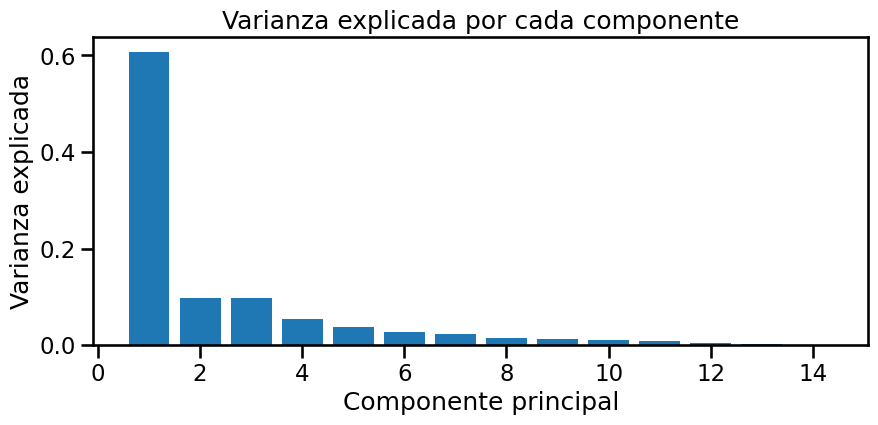

Varianza explicada por las 2 primeras componentes: 0.706
Shape PCA: (13463, 2)


In [15]:
from sklearn.decomposition import PCA

# n = mínimo entre 20 y la cantidad de columnas (features)
n_components = min(20, X_imputed.shape[1])

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_imputed)

# Cuánta varianza explica cada componente
plt.figure(figsize=(10, 4))
plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_)
plt.xlabel('Componente principal')
plt.ylabel('Varianza explicada')
plt.title('Varianza explicada por cada componente')
plt.show()

print("Varianza explicada por las 2 primeras componentes:",
      pca.explained_variance_ratio_[:2].sum().round(3))

# Tomamos solo las 2 primeras columnas para agregar como nuevas features
X_pca_2 = X_pca[:, :2]
print("Shape PCA:", X_pca_2.shape)

## Ejercicio 4: Composición del resultado

Transformar nuevamente el conjunto de datos procesado en un `pandas.DataFrame` y guardarlo en un archivo.

Para eso, será necesario recordar el nombre original de cada columna de la matriz, en el orden correcto. Tener en cuenta:
1. El método `OneHotEncoder.get_feature_names` o el atributo `OneHotEncoder.categories_` permiten obtener una lista con los valores de la categoría que le corresponde a cada índice de la matriz.
2. Ninguno de los métodos aplicados intercambia de lugar las columnas o las filas de la matriz.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Concatenar las 2 componentes PCA a la matriz imputada
X_final = np.hstack([X_imputed, X_pca_2])

# Construir los nombres de columnas en el mismo orden
nombres_num  = num_cols                                        # variables numéricas
nombres_cat  = list(encoder.get_feature_names_out(cat_cols))  # columnas OHE
nombres_imputadas = ['YearBuilt', 'BuildingArea']
nombres_pca  = ['PCA_1', 'PCA_2']

todas_las_columnas = nombres_num + nombres_cat + nombres_imputadas + nombres_pca

print("Columnas esperadas:", len(todas_las_columnas))
print("Columnas en X_final:", X_final.shape[1])

# Reconstruir el DataFrame
result_df = pd.DataFrame(X_final, columns=todas_las_columnas)

# Guardar
result_df.to_csv('melb_procesado.csv', index=False)

print("Shape final:", result_df.shape)
result_df.head()

El DataFrame final tiene


*   columnas numéricas originales (Rooms, Price, Distance, etc).
*   columnas de OHE (Suburb, Type, Method, Regionanme, CouncilArea).
*   2 columnas imputadas por KNN (YearBuilt, BuildingArea).
*   2 componentes principales (PCA_1, PCA_2)
Para un total de N columnas





## Ejercicio 5: Documentación

En un documento `.pdf` o `.md` realizar un reporte de las operaciones que realizaron para obtener el conjunto de datos final. Se debe incluir:
  1. Criterios de exclusión (o inclusión) de filas o columnas
  2. Interpretación de las columnas presentes
  2. Todas las transofrmaciones realizadas

Este documento es de uso técnico exclusivamente, y su objetivo es permitir que otres desarrolladores puedan reproducir los mismos pasos y obtener el mismo resultado. Debe ser detallado pero consiso. Por ejemplo:

```
  ## Criterios de exclusión de ejemplos
  1. Se eliminan ejemplos donde el año de construcción es previo a 1900

  ## Características seleccionadas
  ### Características categóricas
  1. Type: tipo de propiedad. 3 valores posibles
  2. ...
  Todas las características categóricas fueron codificadas con un
  método OneHotEncoding utilizando como máximo sus 30 valores más
  frecuentes.
  
  ### Características numéricas
  1. Rooms: Cantidad de habitaciones
  2. Distance: Distancia al centro de la ciudad.
  3. airbnb_mean_price: Se agrega el precio promedio diario de
     publicaciones de la plataforma AirBnB en el mismo código
     postal. [Link al repositorio con datos externos].

  ### Transformaciones:
  1. Todas las características numéricas fueron estandarizadas.
  2. La columna `Suburb` fue imputada utilizando el método ...
  3. Las columnas `YearBuilt` y ... fueron imputadas utilizando el
     algoritmo ...
  4. ...

  ### Datos aumentados
  1. Se agregan las 5 primeras columnas obtenidas a través del
     método de PCA, aplicado sobre el conjunto de datos
     totalmente procesado.
```
